<a href="https://colab.research.google.com/github/grov3000/project/blob/main/%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82_%D0%9D%D0%98%D0%A1_%D0%B1%D0%B8%D0%BD%D0%B0%D1%80%D0%BD%D0%B0%D1%8F_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Цель проекта

Цель проекта — построить модель машинного обучения, которая по характеристикам кофе и тексту обзора предсказывает, будет ли оценка кофе выше средней по датасету.

Задача формулируется как бинарная классификация:
- 0 — оценка кофе ниже средней;
- 1 — оценка кофе выше средней.

Ищем данные для нашего датасета на сайте "Coffee Review"

In [ ]:
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm

headers = {
    "User-Agent": "Mozilla/5.0"
}

review_links = []

for page in range(1, 51):

    url = f"https://www.coffeereview.com/review/page/{page}/"

    r = requests.get(url, headers=headers)

    if r.status_code != 200:
        print("Ошибка страницы", page)
        continue

    soup = BeautifulSoup(r.text, "html.parser")

    for a in soup.select("a"):

        href = a.get("href")

        if href and "/review/" in href:

            if (
                href != "https://www.coffeereview.com/review/"
                and "/review/page/" not in href
            ):
                review_links.append(href)

review_links = list(set(review_links))

print("Найдено обзоров:", len(review_links))
print(review_links[:5])

Найдено обзоров: 1000
['https://www.coffeereview.com/review/ethiopia-yirgacheffe-gotiti-angel-geisha-natural-espresso/', 'https://www.coffeereview.com/review/rotheca-decaf-kirundu-burundi/', 'https://www.coffeereview.com/review/ethiopia-natural-lion-88/', 'https://www.coffeereview.com/review/ethiopia-sidama-natural-dur-feres/', 'https://www.coffeereview.com/review/pikes-place-roast/']


# Описание датасета

Датасет был сформирован на основе отзывов Coffee Review. Каждая строка соответствует одному обзору кофе.

Признаки:
- coffee_name — название кофе;
- review_score — экспертная оценка;
- coffee_origin — происхождение кофе;
- roast_level — уровень обжарки;
- price — цена;
- review_date — дата обзора;
- review_text — текст экспертного описания;
- url — ссылка на обзор.

In [ ]:
import pandas as pd
import re

data = []

for link in tqdm(review_links):

    try:

        r = requests.get(link, headers=headers, timeout=15)

        soup = BeautifulSoup(r.text, "html.parser")

        text = soup.get_text("\n")

        score = None

        score_match = re.search(r"\n(9\d|8\d|7\d)\n", text)

        if score_match:
            score = int(score_match.group(1))

        title = soup.find("h1")

        coffee_name = title.text.strip() if title else ""

        roaster = ""
        origin = ""
        roast_level = ""
        price = ""
        review_date = ""

        patterns = {
            "Roaster Location:": "roaster",
            "Coffee Origin:": "origin",
            "Roast Level:": "roast_level",
            "Est. Price:": "price",
            "Review Date:": "review_date"
        }

        lines = [x.strip() for x in text.split("\n") if x.strip()]

        for i, line in enumerate(lines):

            if line.startswith("Coffee Origin"):
                if i + 1 < len(lines):
                    origin = lines[i + 1]

            elif line.startswith("Roast Level"):
                if i + 1 < len(lines):
                    roast_level = lines[i + 1]

            elif line.startswith("Est. Price"):
                if i + 1 < len(lines):
                    price = lines[i + 1]

            elif line.startswith("Review Date"):
                if i + 1 < len(lines):
                    review_date = lines[i + 1]

        review_text = ""

        if "Blind Assessment" in text:

            start = text.find("Blind Assessment")

            end = text.find("Notes")

            if end == -1:
                end = start + 1500

            review_text = text[start:end]

        data.append({
            "coffee_name": coffee_name,
            "review_score": score,
            "coffee_origin": origin,
            "roast_level": roast_level,
            "price": price,
            "review_date": review_date,
            "review_text": review_text,
            "url": link
        })

    except Exception as e:
        print("Ошибка:", link, e)

df = pd.DataFrame(data)

print(df.shape)

df.head()

100%|██████████| 1000/1000 [09:52<00:00,  1.69it/s]

(1000, 8)


,coffee_name,review_score,coffee_origin,roast_level,price,review_date,review_text,url
0,Ethiopia Yirgacheffe Gotiti Angel Geisha Natur...,96,"Yirgacheffe growing region, south-central Ethi...",Medium,NT $550/200 grams,July 2025,Blind Assessment\n\n\nEvaluated as espresso. S...,https://www.coffeereview.com/review/ethiopia-y...
1,Rotheca Decaf Kirundu Burundi,90,"Kirundu, Burundi",Medium,$26.40/12 ounces,April 2026,Blind Assessment\n\n\nGently classic decaf. Co...,https://www.coffeereview.com/review/rotheca-de...
2,Ethiopia Natural Lion 88,94,"Guji Zone, Oromia region, southern Ethiopia",Medium-Light,NT $500/8 ounces,November 2024,"Blind Assessment\n\n\nDelicately sweet-tart, b...",https://www.coffeereview.com/review/ethiopia-n...
3,Ethiopia Sidama Natural Dur Feres,93,"Sidamo growing region, south-central Ethiopia",Medium-Light,$26.00/12 ounces,September 2025,"Blind Assessment\n\n\nRichly sweet, deeply fru...",https://www.coffeereview.com/review/ethiopia-s...
4,Pike’s Place Roast,78,Latin America,Very Dark,$9.99/12 ounces,February 2025,"Blind Assessment\n\n\nHarsh, bitter. Charcoal,...",https://www.coffeereview.com/review/pikes-plac...


Загрузка датасета

In [ ]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("coffee_reviews_dataset.csv")

df.head()

,coffee_name,review_score,coffee_origin,roast_level,price,review_date,review_text,url
0,Ethiopia Yirgacheffe Gotiti Angel Geisha Natur...,96,"Yirgacheffe growing region, south-central Ethi...",Medium,NT $550/200 grams,July 2025,Blind Assessment\n\n\nEvaluated as espresso. S...,https://www.coffeereview.com/review/ethiopia-y...
1,Rotheca Decaf Kirundu Burundi,90,"Kirundu, Burundi",Medium,$26.40/12 ounces,April 2026,Blind Assessment\n\n\nGently classic decaf. Co...,https://www.coffeereview.com/review/rotheca-de...
2,Ethiopia Natural Lion 88,94,"Guji Zone, Oromia region, southern Ethiopia",Medium-Light,NT $500/8 ounces,November 2024,"Blind Assessment\n\n\nDelicately sweet-tart, b...",https://www.coffeereview.com/review/ethiopia-n...
3,Ethiopia Sidama Natural Dur Feres,93,"Sidamo growing region, south-central Ethiopia",Medium-Light,$26.00/12 ounces,September 2025,"Blind Assessment\n\n\nRichly sweet, deeply fru...",https://www.coffeereview.com/review/ethiopia-s...
4,Pike’s Place Roast,78,Latin America,Very Dark,$9.99/12 ounces,February 2025,"Blind Assessment\n\n\nHarsh, bitter. Charcoal,...",https://www.coffeereview.com/review/pikes-plac...


# 1. Разведочный анализ данных (EDA)

На этом этапе проводится первичный анализ датасета: изучается размер таблицы, типы данных, наличие пропусков, распределение оценок кофе и структура признаков.

In [ ]:
df.shape

(1000, 8)

In [ ]:
df.head()

,coffee_name,review_score,coffee_origin,roast_level,price,review_date,review_text,url
0,Ethiopia Yirgacheffe Gotiti Angel Geisha Natur...,96,"Yirgacheffe growing region, south-central Ethi...",Medium,NT $550/200 grams,July 2025,Blind Assessment\n\n\nEvaluated as espresso. S...,https://www.coffeereview.com/review/ethiopia-y...
1,Rotheca Decaf Kirundu Burundi,90,"Kirundu, Burundi",Medium,$26.40/12 ounces,April 2026,Blind Assessment\n\n\nGently classic decaf. Co...,https://www.coffeereview.com/review/rotheca-de...
2,Ethiopia Natural Lion 88,94,"Guji Zone, Oromia region, southern Ethiopia",Medium-Light,NT $500/8 ounces,November 2024,"Blind Assessment\n\n\nDelicately sweet-tart, b...",https://www.coffeereview.com/review/ethiopia-n...
3,Ethiopia Sidama Natural Dur Feres,93,"Sidamo growing region, south-central Ethiopia",Medium-Light,$26.00/12 ounces,September 2025,"Blind Assessment\n\n\nRichly sweet, deeply fru...",https://www.coffeereview.com/review/ethiopia-s...
4,Pike’s Place Roast,78,Latin America,Very Dark,$9.99/12 ounces,February 2025,"Blind Assessment\n\n\nHarsh, bitter. Charcoal,...",https://www.coffeereview.com/review/pikes-plac...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   coffee_name    1000 non-null   object
 1   review_score   1000 non-null   int64 
 2   coffee_origin  999 non-null    object
 3   roast_level    997 non-null    object
 4   price          1000 non-null   object
 5   review_date    1000 non-null   object
 6   review_text    1000 non-null   object
 7   url            1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 62.6+ KB


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
roast_level,3
coffee_origin,1
review_score,0
coffee_name,0
price,0
review_date,0
review_text,0
url,0


In [ ]:
df.duplicated().sum()

np.int64(0)

## Анализ оценки кофе

Основная числовая переменная в датасете — `review_score`. Она отражает экспертную оценку кофе. На её основе далее будет построена бинарная целевая переменная: кофе ниже средней оценки и кофе выше средней оценки.

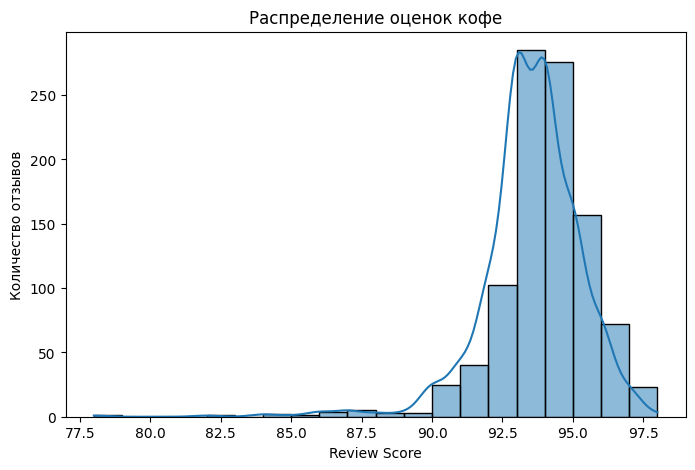

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["review_score"], bins=20, kde=True)
plt.title("Распределение оценок кофе")
plt.xlabel("Review Score")
plt.ylabel("Количество отзывов")
plt.show()

In [ ]:
print("Минимальная оценка:", df["review_score"].min())
print("Максимальная оценка:", df["review_score"].max())
print("Средняя оценка:", df["review_score"].mean())

Минимальная оценка: 78
Максимальная оценка: 98
Средняя оценка: 93.506


# 2. Формирование целевой переменной

Вместо произвольного порога премиальности используется средняя оценка кофе по датасету.

Если `review_score` больше или равен средней оценке, объект относится к классу `above_average`.

Если `review_score` ниже средней оценки, объект относится к классу `below_average`.

Таким образом задача сводится к бинарной классификации.

Средняя оценка кофе: 93.506


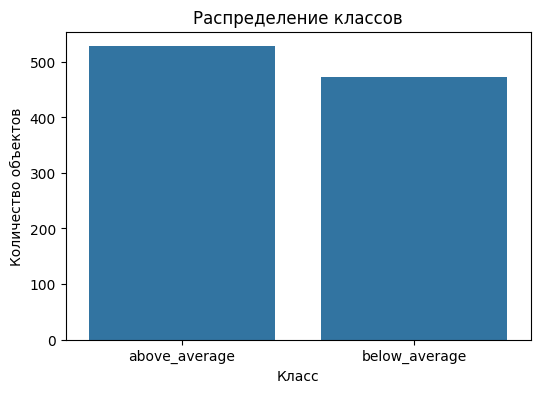

In [ ]:
mean_score = df["review_score"].mean()

df["above_average"] = (df["review_score"] >= mean_score).astype(int)

df["average_class"] = df["above_average"].map({
    0: "below_average",
    1: "above_average"
})

print("Средняя оценка кофе:", mean_score)
df["average_class"].value_counts()
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="average_class")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

In [ ]:
df[["coffee_name", "review_score", "above_average", "average_class"]].head(10)

,coffee_name,review_score,above_average,average_class
0,Ethiopia Yirgacheffe Gotiti Angel Geisha Natur...,96,1,above_average
1,Rotheca Decaf Kirundu Burundi,90,0,below_average
2,Ethiopia Natural Lion 88,94,1,above_average
3,Ethiopia Sidama Natural Dur Feres,93,0,below_average
4,Pike’s Place Roast,78,0,below_average
5,Papua New Guinea Big Red,93,0,below_average
6,Thailand Bluekoff Plantation Washed,92,0,below_average
7,Costa Rica Rio Negro,93,0,below_average
8,Yunlin Natural SL34,93,0,below_average
9,Rose Lili,93,0,below_average


## Анализ категориальных признаков

В датасете присутствуют категориальные признаки: происхождение кофе и уровень обжарки. Они могут быть связаны с итоговой оценкой, поэтому используются в модели.

In [ ]:
df["roast_level"].value_counts(dropna=False)

,count
roast_level,
Medium,461
Medium-Light,436
Medium-Dark,70
Light,15
Dark,9
Very Dark,6
NaN,3


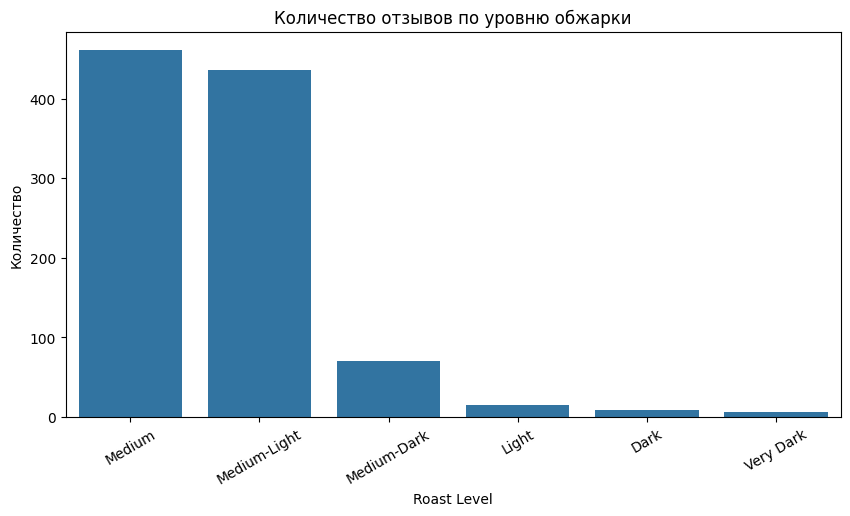

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="roast_level", order=df["roast_level"].value_counts().index)
plt.title("Количество отзывов по уровню обжарки")
plt.xlabel("Roast Level")
plt.ylabel("Количество")
plt.xticks(rotation=30)
plt.show()

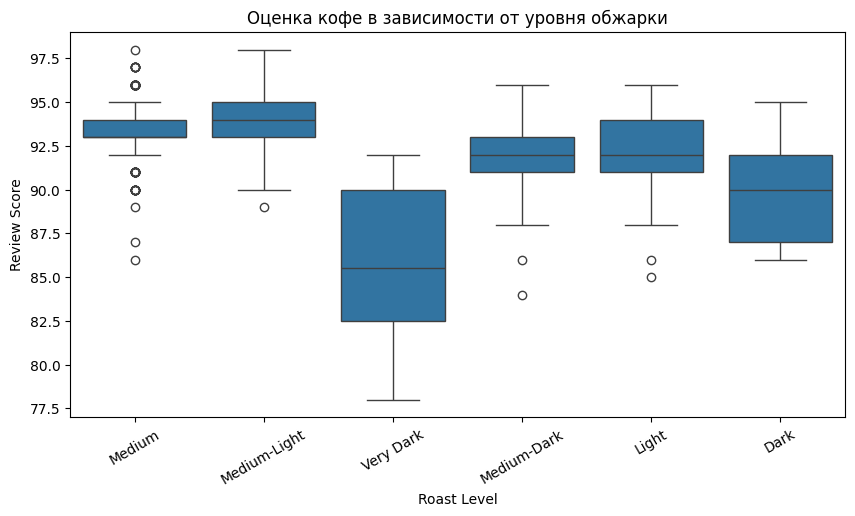

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="roast_level", y="review_score")
plt.title("Оценка кофе в зависимости от уровня обжарки")
plt.xlabel("Roast Level")
plt.ylabel("Review Score")
plt.xticks(rotation=30)
plt.show()

# 3. Подготовка признаков

Для обучения модели используются табличные и текстовые признаки.

Из поля `coffee_origin` извлекается страна или регион происхождения кофе.  
Из поля `price` извлекается числовое значение цены.  
Из даты обзора извлекается год.  
Из текста отзыва формируются дополнительные признаки: длина текста, количество слов, количество положительных и отрицательных маркеров.

In [ ]:
countries = [
    "Ethiopia",
    "Colombia",
    "Brazil",
    "Kenya",
    "Burundi",
    "Guatemala",
    "Costa Rica",
    "Panama",
    "Peru",
    "Rwanda",
    "Honduras",
    "Indonesia",
    "Mexico",
    "China",
    "El Salvador",
    "Nicaragua",
    "Uganda",
    "Tanzania",
    "Latin America",
    "Hawaii",
    "Taiwan",
    "Papua New Guinea",
    "Thailand"
]

def extract_country(text):
    text = str(text)
    for country in countries:
        if country.lower() in text.lower():
            return country
    return "Unknown"

df["country"] = df["coffee_origin"].apply(extract_country)

In [ ]:
def extract_price(text):
    match = re.search(r"(\d+\.?\d*)", str(text))
    if match:
        return float(match.group(1))
    return np.nan

df["price_numeric"] = df["price"].apply(extract_price)

In [ ]:
df["year"] = (
    df["review_date"]
    .astype(str)
    .str.extract(r"(\d{4})")
    .astype(float)
)

In [ ]:
df["review_text"] = df["review_text"].fillna("")

df["review_length"] = df["review_text"].apply(len)

df["word_count"] = df["review_text"].apply(lambda x: len(str(x).split()))

In [ ]:
positive_words = [
    "sweet",
    "floral",
    "berry",
    "chocolate",
    "balanced",
    "rich",
    "bright",
    "elegant",
    "complex",
    "vibrant",
    "jasmine",
    "citrus",
    "honey",
    "juicy",
    "clean",
    "silky",
    "smooth",
    "deep",
    "resonant"
]

negative_words = [
    "bitter",
    "harsh",
    "flat",
    "burnt",
    "rough",
    "astringent",
    "dry",
    "dull",
    "scorched",
    "thin",
    "muted"
]

def count_words(text, words):
    text = str(text).lower()
    return sum(text.count(word) for word in words)

df["positive_word_count"] = df["review_text"].apply(lambda x: count_words(x, positive_words))
df["negative_word_count"] = df["review_text"].apply(lambda x: count_words(x, negative_words))

In [ ]:
df[
    [
        "coffee_origin",
        "country",
        "price",
        "price_numeric",
        "review_date",
        "year",
        "review_length",
        "word_count",
        "positive_word_count",
        "negative_word_count"
    ]
].head()

,coffee_origin,country,price,price_numeric,review_date,year,review_length,word_count,positive_word_count,negative_word_count
0,"Yirgacheffe growing region, south-central Ethi...",Ethiopia,NT $550/200 grams,550.00,July 2025,2025.0,366,46,6,0
1,"Kirundu, Burundi",Burundi,$26.40/12 ounces,26.40,April 2026,2026.0,218,33,2,1
2,"Guji Zone, Oromia region, southern Ethiopia",Ethiopia,NT $500/8 ounces,500.00,November 2024,2024.0,314,40,8,0
3,"Sidamo growing region, south-central Ethiopia",Ethiopia,$26.00/12 ounces,26.00,September 2025,2025.0,276,40,9,1
4,Latin America,Latin America,$9.99/12 ounces,9.99,February 2025,2025.0,172,24,1,5


# 4. Формирование обучающей выборки

Для модели используются следующие группы признаков:

- категориальные признаки: страна происхождения, уровень обжарки;
- числовые признаки: цена, год, длина текста, количество слов, количество положительных и отрицательных слов;
- текстовый признак: полный текст отзыва.

Целевая переменная — `above_average`.

In [ ]:
model_df = df[
    [
        "country",
        "roast_level",
        "price_numeric",
        "year",
        "review_length",
        "word_count",
        "positive_word_count",
        "negative_word_count",
        "review_text",
        "above_average"
    ]
].copy()

model_df.head()

,country,roast_level,price_numeric,year,review_length,word_count,positive_word_count,negative_word_count,review_text,above_average
0,Ethiopia,Medium,550.00,2025.0,366,46,6,0,Blind Assessment\n\n\nEvaluated as espresso. S...,1
1,Burundi,Medium,26.40,2026.0,218,33,2,1,Blind Assessment\n\n\nGently classic decaf. Co...,0
2,Ethiopia,Medium-Light,500.00,2024.0,314,40,8,0,"Blind Assessment\n\n\nDelicately sweet-tart, b...",1
3,Ethiopia,Medium-Light,26.00,2025.0,276,40,9,1,"Blind Assessment\n\n\nRichly sweet, deeply fru...",0
4,Latin America,Very Dark,9.99,2025.0,172,24,1,5,"Blind Assessment\n\n\nHarsh, bitter. Charcoal,...",0


In [ ]:
model_df.isna().sum().sort_values(ascending=False)

,0
roast_level,3
country,0
price_numeric,0
year,0
review_length,0
word_count,0
positive_word_count,0
negative_word_count,0
review_text,0
above_average,0


In [ ]:
model_df["above_average"].value_counts(normalize=True)

,proportion
above_average,
1,0.528
0,0.472


# 5. Разделение данных

Данные разделяются на обучающую и тестовую выборки в соотношении 80/20.  
Для сохранения распределения классов используется параметр `stratify`.

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df.drop("above_average", axis=1)
y = model_df["above_average"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 9)
X_test: (200, 9)
y_train: (800,)
y_test: (200,)


In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

above_average
1    422
0    378
Name: count, dtype: int64
above_average
1    106
0     94
Name: count, dtype: int64


# 6. Предобработка данных

Для разных типов признаков используются разные методы обработки.

Числовые признаки заполняются медианой и масштабируются.  
Категориальные признаки заполняются наиболее частым значением и кодируются методом One-Hot Encoding.  
Текст отзыва преобразуется в числовой вид с помощью TF-IDF.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

numeric_features = [
    "price_numeric",
    "year",
    "review_length",
    "word_count",
    "positive_word_count",
    "negative_word_count"
]

categorical_features = [
    "country",
    "roast_level"
]

text_feature = "review_text"

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

text_transformer = TfidfVectorizer(
    stop_words="english",
    max_features=2500,
    ngram_range=(1, 2),
    min_df=2
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("text", text_transformer, text_feature)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['price_numeric', 'year', 'review_length',
                                  'word_count', 'positive_word_count',
                                  'negative_word_count']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['country', 'roast_level']),
                                ('text',
                                 TfidfVectorizer(max_features=2500, min_df=2,
                                                 ngram_range=(1, 2),
                                                 stop_words='english'),
                                 'review_text')])

# 7. Базовая модель

Сначала используется Dummy Classifier. Он нужен как базовый ориентир: более сложные модели должны показывать качество выше, чем простое предсказание наиболее частого класса.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

dummy_model = DummyClassifier(strategy="most_frequent")

dummy_model.fit(X_train, y_train)

pred_dummy = dummy_model.predict(X_test)

dummy_accuracy = accuracy_score(y_test, pred_dummy)
dummy_precision = precision_score(y_test, pred_dummy, zero_division=0)
dummy_recall = recall_score(y_test, pred_dummy, zero_division=0)
dummy_f1 = f1_score(y_test, pred_dummy, zero_division=0)

print("Dummy Classifier")
print("Accuracy:", dummy_accuracy)
print("Precision:", dummy_precision)
print("Recall:", dummy_recall)
print("F1:", dummy_f1)

Dummy Classifier
Accuracy: 0.53
Precision: 0.53
Recall: 1.0
F1: 0.6928104575163399


# 8. Logistic Regression

Логистическая регрессия используется как основная интерпретируемая модель классификации.  
Она хорошо подходит для работы с TF-IDF-признаками и позволяет анализировать вклад отдельных слов и признаков.

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

pred_log = log_reg_pipeline.predict(X_test)
proba_log = log_reg_pipeline.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test, pred_log)
log_precision = precision_score(y_test, pred_log)
log_recall = recall_score(y_test, pred_log)
log_f1 = f1_score(y_test, pred_log)
log_roc_auc = roc_auc_score(y_test, proba_log)

print("Logistic Regression")
print("Accuracy:", log_accuracy)
print("Precision:", log_precision)
print("Recall:", log_recall)
print("F1:", log_f1)
print("ROC-AUC:", log_roc_auc)

print(classification_report(
    y_test,
    pred_log,
    target_names=["below_average", "above_average"]
))

Logistic Regression
Accuracy: 0.82
Precision: 0.8365384615384616
Recall: 0.8207547169811321
F1: 0.8285714285714286
ROC-AUC: 0.9089723002810116
               precision    recall  f1-score   support

below_average       0.80      0.82      0.81        94
above_average       0.84      0.82      0.83       106

     accuracy                           0.82       200
    macro avg       0.82      0.82      0.82       200
 weighted avg       0.82      0.82      0.82       200



# 9. Random Forest Classifier

Случайный лес используется как нелинейная модель для сравнения с логистической регрессией.  
Модель может учитывать более сложные зависимости между признаками, однако для текстовых TF-IDF-признаков часто оказывается менее интерпретируемой.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

pred_rf = rf_pipeline.predict(X_test)
proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, pred_rf)
rf_precision = precision_score(y_test, pred_rf)
rf_recall = recall_score(y_test, pred_rf)
rf_f1 = f1_score(y_test, pred_rf)
rf_roc_auc = roc_auc_score(y_test, proba_rf)

print("Random Forest Classifier")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1:", rf_f1)
print("ROC-AUC:", rf_roc_auc)

print(classification_report(
    y_test,
    pred_rf,
    target_names=["below_average", "above_average"]
))

Random Forest Classifier
Accuracy: 0.815
Precision: 0.8349514563106796
Recall: 0.8113207547169812
F1: 0.8229665071770335
ROC-AUC: 0.9175030108390205
               precision    recall  f1-score   support

below_average       0.79      0.82      0.81        94
above_average       0.83      0.81      0.82       106

     accuracy                           0.81       200
    macro avg       0.81      0.82      0.81       200
 weighted avg       0.82      0.81      0.82       200



# 10. Сравнение моделей

Модели сравниваются по Accuracy, Precision, Recall, F1 и ROC-AUC.  
Так как классы почти сбалансированы, Accuracy можно учитывать, но основной упор делается на F1 и ROC-AUC.

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Random Forest Classifier"
    ],
    "Accuracy": [
        dummy_accuracy,
        log_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dummy_precision,
        log_precision,
        rf_precision
    ],
    "Recall": [
        dummy_recall,
        log_recall,
        rf_recall
    ],
    "F1": [
        dummy_f1,
        log_f1,
        rf_f1
    ],
    "ROC-AUC": [
        0.5,
        log_roc_auc,
        rf_roc_auc
    ]
})

results.sort_values("F1", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Logistic Regression,0.820,0.836538,0.820755,0.828571,0.908972
2,Random Forest Classifier,0.815,0.834951,0.811321,0.822967,0.917503
0,Dummy Classifier,0.530,0.530000,1.000000,0.692810,0.500000


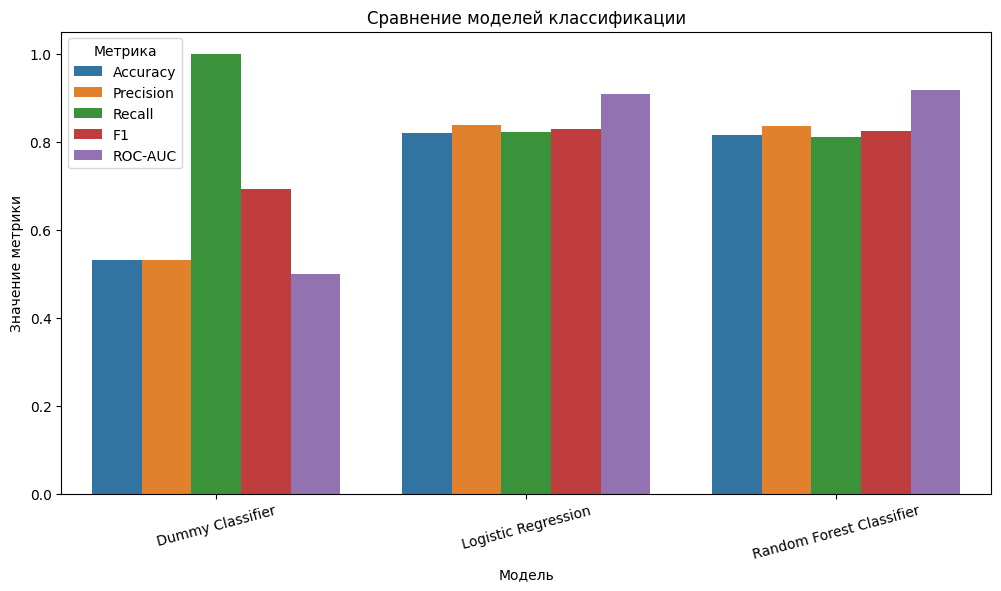

In [ ]:
results_melted = results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric")
plt.title("Сравнение моделей классификации")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(title="Метрика")
plt.show()

# 11. Матрица ошибок

Матрица ошибок показывает, сколько объектов модель правильно и неправильно отнесла к классам below_average и above_average.

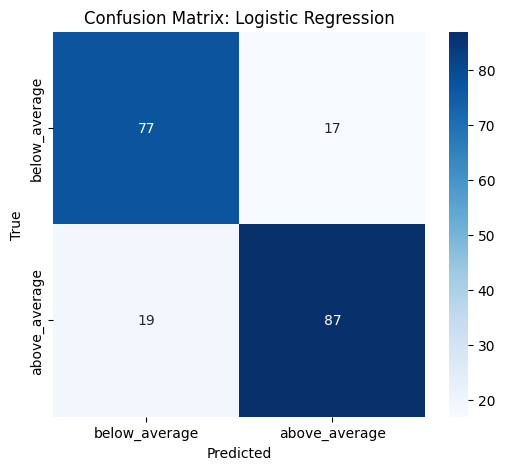

In [ ]:
cm = confusion_matrix(y_test, pred_log)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["below_average", "above_average"],
    yticklabels=["below_average", "above_average"]
)

plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 12. Кросс-валидация

Кросс-валидация позволяет получить более устойчивую оценку качества модели, так как модель обучается и проверяется на нескольких разных разбиениях данных.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_f1 = cross_val_score(
    log_reg_pipeline,
    X,
    y,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

cv_roc_auc = cross_val_score(
    log_reg_pipeline,
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("F1 scores:", cv_f1)
print("Mean F1:", cv_f1.mean())
print("Std F1:", cv_f1.std())

print("ROC-AUC scores:", cv_roc_auc)
print("Mean ROC-AUC:", cv_roc_auc.mean())
print("Std ROC-AUC:", cv_roc_auc.std())

F1 scores: [0.85436893 0.77625571 0.83018868 0.8411215  0.82178218]
Mean F1: 0.82474339851832
Std F1: 0.02659093963794071
ROC-AUC scores: [0.93004817 0.84885588 0.89602569 0.9197995  0.92090226]
Mean ROC-AUC: 0.9031263002950976
Std ROC-AUC: 0.029375038419456406


# 13. Подбор гиперпараметров

Для улучшения качества модели используется GridSearchCV.  
Подбираются параметры TF-IDF-векторизации и коэффициент регуляризации Logistic Regression.

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

param_grid = {
    "preprocessor__text__max_features": [1500, 2500],
    "preprocessor__text__ngram_range": [(1, 1), (1, 2)],
    "model__C": [0.5, 1, 2]
}

grid = GridSearchCV(
    estimator=grid_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid.best_params_)

print("Лучший F1 на кросс-валидации:")
print(grid.best_score_)

Лучшие параметры:
{'model__C': 2, 'preprocessor__text__max_features': 1500, 'preprocessor__text__ngram_range': (1, 1)}
Лучший F1 на кросс-валидации:
0.8289408840995388


# 14. Оценка финальной модели

После подбора гиперпараметров лучшая модель проверяется на тестовой выборке.

In [ ]:
best_model = grid.best_estimator_

pred_best = best_model.predict(X_test)
proba_best = best_model.predict_proba(X_test)[:, 1]

best_accuracy = accuracy_score(y_test, pred_best)
best_precision = precision_score(y_test, pred_best)
best_recall = recall_score(y_test, pred_best)
best_f1 = f1_score(y_test, pred_best)
best_roc_auc = roc_auc_score(y_test, proba_best)

print("Final Logistic Regression")
print("Accuracy:", best_accuracy)
print("Precision:", best_precision)
print("Recall:", best_recall)
print("F1:", best_f1)
print("ROC-AUC:", best_roc_auc)

print(classification_report(
    y_test,
    pred_best,
    target_names=["below_average", "above_average"]
))

Final Logistic Regression
Accuracy: 0.83
Precision: 0.86
Recall: 0.8113207547169812
F1: 0.8349514563106796
ROC-AUC: 0.9215174628663187
               precision    recall  f1-score   support

below_average       0.80      0.85      0.82        94
above_average       0.86      0.81      0.83       106

     accuracy                           0.83       200
    macro avg       0.83      0.83      0.83       200
 weighted avg       0.83      0.83      0.83       200



In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression before tuning",
        "Logistic Regression after tuning"
    ],
    "Accuracy": [
        log_accuracy,
        best_accuracy
    ],
    "Precision": [
        log_precision,
        best_precision
    ],
    "Recall": [
        log_recall,
        best_recall
    ],
    "F1": [
        log_f1,
        best_f1
    ],
    "ROC-AUC": [
        log_roc_auc,
        best_roc_auc
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression before tuning,0.82,0.836538,0.820755,0.828571,0.908972
1,Logistic Regression after tuning,0.83,0.860000,0.811321,0.834951,0.921517


# 15. Интерпретация модели

Так как финальная модель — Logistic Regression, можно проанализировать коэффициенты признаков.  
Положительные коэффициенты связаны с классом above_average, отрицательные — с классом below_average.

In [ ]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

coefs = best_model.named_steps["model"].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

top_positive = importance.sort_values("coefficient", ascending=False).head(20)
top_negative = importance.sort_values("coefficient", ascending=True).head(20)

top_positive

,feature,coefficient
372,text__long,3.805491
553,text__sparkling,2.474632
330,text__juicy,2.325346
409,text__narcissus,2.154197
299,text__high,1.915782
245,text__flavor,1.856610
617,text__viscous,1.711531
210,text__elegant,1.672573
559,text__star,1.662405
231,text__expressive,1.607079


In [ ]:
top_negative

,feature,coefficient
172,text__crisp,-2.734045
96,text__briskly,-2.502226
576,text__sweet,-2.428226
62,text__baking,-2.362818
611,text__velvety,-2.304907
361,text__lightly,-2.010695
642,text__zest,-1.949361
95,text__brisk,-1.804336
121,text__cedar,-1.786910
577,text__sweetly,-1.650683


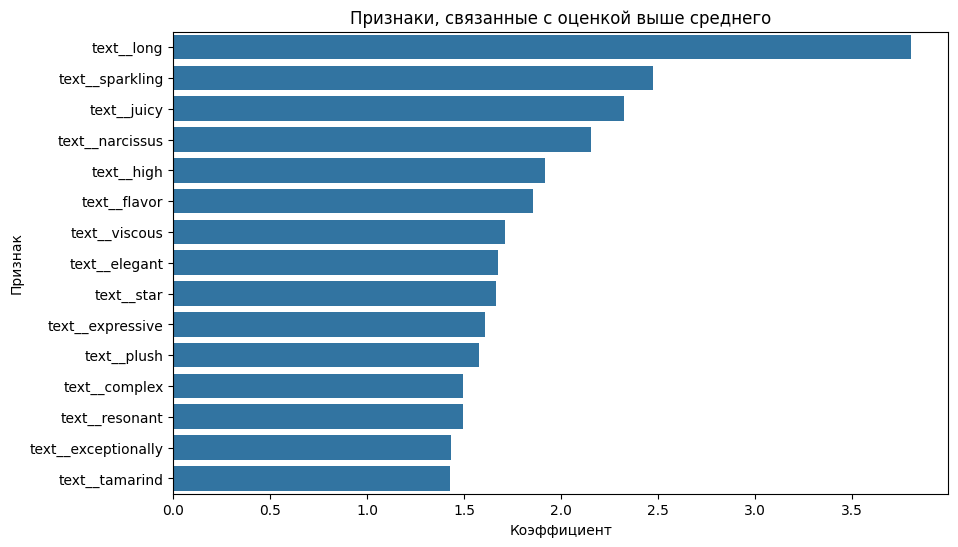

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive.head(15),
    x="coefficient",
    y="feature"
)

plt.title("Признаки, связанные с оценкой выше среднего")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.show()

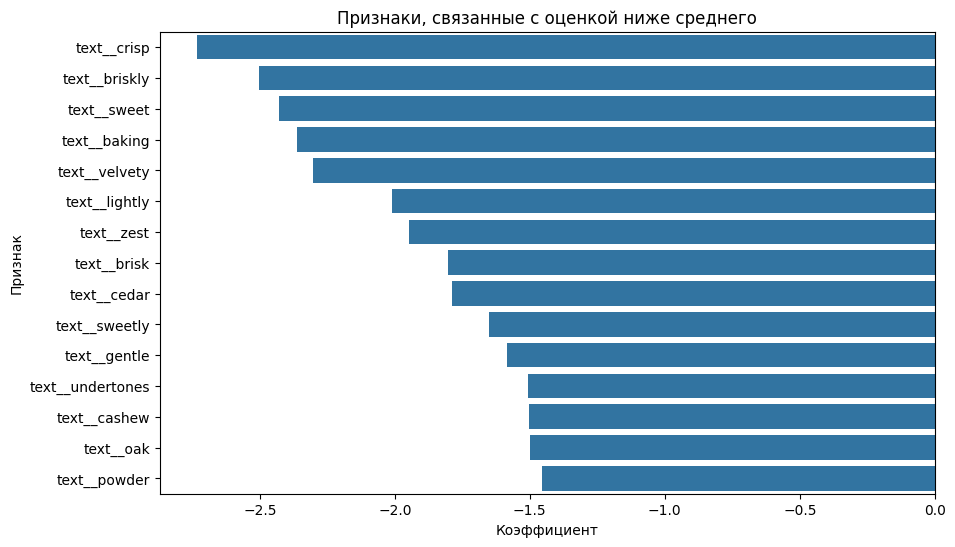

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative.head(15),
    x="coefficient",
    y="feature"
)

plt.title("Признаки, связанные с оценкой ниже среднего")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.show()

# 16. Сохранение модели

Финальная модель сохраняется в формате `.pkl`.  
Этот файл далее используется для интеграции модели в Telegram-бота.

In [ ]:
import joblib

joblib.dump(best_model, "coffee_above_average_classifier.pkl")

df.to_csv("coffee_reviews_with_average_target.csv", index=False, encoding="utf-8-sig")
model_df.to_csv("coffee_model_table.csv", index=False, encoding="utf-8-sig")

print("Модель сохранена: coffee_above_average_classifier.pkl")
print("Датасет сохранён: coffee_reviews_with_average_target.csv")
print("Таблица для модели сохранена: coffee_model_table.csv")

Модель сохранена: coffee_above_average_classifier.pkl
Датасет сохранён: coffee_reviews_with_average_target.csv
Таблица для модели сохранена: coffee_model_table.csv


In [ ]:
from google.colab import files

files.download("coffee_above_average_classifier.pkl")
files.download("coffee_reviews_with_average_target.csv")
files.download("coffee_model_table.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>